 The file should be completed so that the neural network classifies points on the plane into appropriate classes, as shown in the figure below. The task should be completed using the analytical method consisting in manual calculation of network weights and entering their values into appropriate structures, as well as the learning method based on a maximum of 30 selected training examples (points on the plane with labels).

Classification of points (images) lying on one side of the curve - the decision boundary:
                     

In [1]:
#                  (1,3)                (3,3)
#                       o-----------------o
#                      /                   \      class 0
#                     /                     \
#                    /                       \
#                   /                         \
# -----------------o  (-1,1)            (5,1)  o-------------------------------------------
#
#                              class 1

import time
import os.path
import pdb
import matplotlib.pyplot as plt
import numpy as np
import tensorflow.compat.v1 as tf
print(tf.__version__)
# if tensorflow2 use tf.compat.v1. apart tf. (see classification2 script)
tf.compat.v1.disable_eager_execution()

2.20.0


In [2]:
num_of_features = 2
num_of_epochs = 1000
num_to_show = 50

sess = tf.InteractiveSession()

x = tf.placeholder(tf.float32, shape=[None, num_of_features])  # place for input vectors
y_ = tf.placeholder(tf.float32, shape=[None, 1])               # place for desired output of ANN

### Analytical version
(See more: https://udlbook.github.io/udlbook/ )

In [4]:
my_tensor = tf.constant([[ 1.,  0., -1.], [-1., -1., -1.]],dtype=float)
IW_a = tf.Variable(my_tensor)                                # 1-st level weights
b1_a = tf.Variable(tf.constant([2., 3., 6.],dtype=float))      # 1-st level biases -||-

In [5]:
# output values from 1-st level:
h1_a = tf.cast(tf.greater_equal(tf.matmul(x, IW_a) + b1_a, 0), tf.float32)
                                                             # use sharp threshold activation function like:
                                                             #
                                                             #          ---------
                                                             #          |
                                                             #   --------

In [6]:
LW21_a = tf.Variable(tf.constant([
    [1.],
    [1.],
    [1.]
], dtype=tf.float32))           # 2-nd level weights values - analytical version
b2_a = tf.Variable(tf.constant([-2.5], dtype=tf.float32))

In [7]:
s_a = tf.matmul(h1_a, LW21_a) + b2_a

y_a = tf.cast(tf.greater_equal(s_a, 0), tf.float32)   # output flom ANN

y = tf.sigmoid(s_a)                                   # (single value using sigmoidal act.funct in range (0,1))

### Trainable version

In [13]:
IW = tf.Variable(tf.random_normal([2, 3], stddev=0.5), dtype=tf.float32)             # 1-st level weights
b1 = tf.Variable(tf.zeros([3]), dtype=tf.float32)                                    # 1-st level biases -||-

In [14]:
h1 = tf.sigmoid(tf.matmul(x, IW) + b1)                          # use continuous version of activation function

In [15]:
LW21 = tf.Variable(tf.random_normal([3, 1], stddev=0.5), dtype=tf.float32)           # 2-nd level weights values
b2 = tf.Variable(tf.zeros([1]), dtype=tf.float32)                                    # 2-nd level bias values

# LW32 = .................           # maybe 3-d layer
# b3 = ...................

In [16]:
mean_square_error = tf.reduce_mean(tf.reduce_sum((y_ - y)*(y_ - y), reduction_indices=[1]))          # MSE loss function
cross_entropy = tf.reduce_mean(-tf.reduce_sum(y_ * tf.log(y) + y*tf.log(y_+0.001), reduction_indices=[1])) # full cross-entropy loss function

train_step = tf.train.GradientDescentOptimizer(0.5).minimize(mean_square_error)   # training method, step value, loss function
                                                                              # You can choose loss function

init = tf.global_variables_initializer()

sess = tf.Session()
sess.run(init)


In [17]:
train_x = np.array([
    # left
    [-1.0, 1.3], [-1.0, 0.7],
    [-0.5, 1.8], [-0.5, 1.2],
    [ 0.0, 2.3], [ 0.0, 1.7],
    [ 0.5, 2.8], [ 0.5, 2.2],
    [ 1.0, 3.3], [ 1.0, 2.7],

    # middle
    [1.2, 3.3], [1.2, 2.7],
    [1.6, 3.3], [1.6, 2.7],
    [2.0, 3.3], [2.0, 2.7],
    [2.4, 3.3], [2.4, 2.7],
    [2.8, 3.3], [2.8, 2.7],

    # right
    [3.0, 3.3], [3.0, 2.7],
    [3.5, 2.8], [3.5, 2.2],
    [4.0, 2.3], [4.0, 1.7],
    [4.5, 1.8], [4.5, 1.2],
    [5.0, 1.3], [5.0, 0.7],
], dtype=np.float32)

train_y = np.array([
    [0], [1],
    [0], [1],
    [0], [1],
    [0], [1],
    [0], [1],

    [0], [1],
    [0], [1],
    [0], [1],
    [0], [1],
    [0], [1],

    [0], [1],
    [0], [1],
    [0], [1],
    [0], [1],
    [0], [1],
], dtype=np.float32)

#### The training process

In [18]:
# ........................................................
# ........................................................
for epoch in range(num_of_epochs):
    _, error_value = sess.run(
        [train_step, mean_square_error],
        feed_dict={
            x: train_x,
            y_: train_y
        }
    )

    if epoch % 100 == 0:
        print("Epoch:", epoch, "error:", error_value)

Epoch: 0 error: 0.12796924
Epoch: 100 error: 0.0919224
Epoch: 200 error: 0.07314543
Epoch: 300 error: 0.060328413
Epoch: 400 error: 0.05100684
Epoch: 500 error: 0.04393926
Epoch: 600 error: 0.038419377
Epoch: 700 error: 0.034008358
Epoch: 800 error: 0.030417021
Epoch: 900 error: 0.027446724


#### Drawing decision boundary

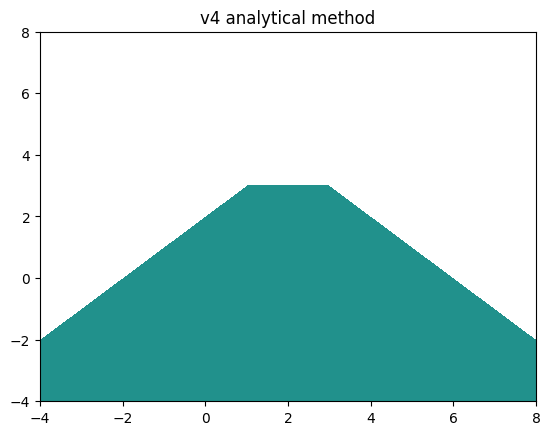

In [19]:
sess.run(tf.global_variables_initializer())
X1, X2 = np.meshgrid(np.linspace(-4, 8, 120), np.linspace(-4,8, 120))  # grid of points in 2D plane
P = np.stack((X1.flatten(),X2.flatten()), axis=1)                    # points formated for ANN input
Y = sess.run(y_a, feed_dict={x: P})                                    # ANN outputs for flatten grid  points
Z = np.reshape(Y,X1.shape)                                           # reshaping to shape of grid
plt.contourf(X1, X2, Z, levels=[0.5, 1.0])                           # curve for level=0.5 - a decision boundary, shaded class 1 area
plt.title('v4 analytical method')
plt.show()


#### Drawing 3D mesh

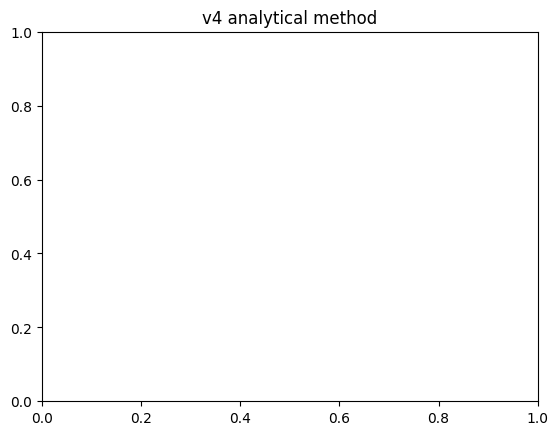

In [20]:
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = Axes3D(fig)
ax.plot_surface(X1, X2, Z, rstride=1, cstride=1, cmap=cm.viridis)
plt.title('v4 analytical method')
plt.show()